### Import Libraries

In [360]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from scipy.stats import median_abs_deviation
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold

### Load the Datasets

In [362]:
combined_df = pd.read_csv('combined_Octoparse_categorized.csv')
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1136 entries, 0 to 1135
Data columns (total 43 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   keyword                                               1136 non-null   object 
 1   Title                                                 1136 non-null   object 
 2   Review_Count                                          1097 non-null   float64
 3   Rating                                                1097 non-null   float64
 4   Address                                               1136 non-null   object 
 5   Country                                               1136 non-null   object 
 6   City                                                  1136 non-null   object 
 7   State                                                 0 non-null      float64
 8   Google_id                                             1136

## Data Pre-processing

In [364]:
#Number of stores per food-chain
keyword_counts = combined_df['keyword'].value_counts()
keyword_counts

keyword
Restaurant     586
Coffee shop    550
Name: count, dtype: int64

In [365]:
# Group by 'Keyword' and calculate mean and median of 'Review_count'
review_stats = combined_df.groupby('keyword')['Review_Count'].agg(['mean', 'median'])

# Display the result
print(review_stats)

                   mean  median
keyword                        
Coffee shop  227.706458    73.0
Restaurant   392.897611    67.0


In [366]:
pd.set_option('display.max_columns', None)
combined_df[combined_df['Indirect Competition - Food & Dining/POI Density'].isnull()]

,keyword,Title,Review_Count,Rating,Address,Country,City,State,Google_id,Place_id,Latitude,Longitude,Category,Price_Range,Current_Status,Transportation & Travel,Hotels & Hospitality,Public & Government Services,Education,Religious Institutions,Home & Construction Services,Finance & Services,Entertainment & Recreation,Retail & Shopping,Health,Beauty & Wellness,Restaurants,Coffee Shops,Food & Dining,POI Density,Avg Rating - Restaurants,Avg Rating - Coffee Shops,Avg Rating - Food & Dining,Avg Num of Reviewers - Restaurants,Avg Num of Reviewers - Coffee Shops,Avg Num of Reviewers - Food & Dining,Total Num of Reviewers - Food & Dining,Direct Competition - Same Category/POI Density,Indirect Competition - Food & Dining/POI Density,Indirect Competition - Opposite Category/POI Density,Population_Within_1km,Population_Within_2km,Population_Within_3km
1050,Restaurant,shawirmarito,10.0,1.5,"655W+J48, Al Khuzama, Al Khobar 34718, Saudi A...",SA,Al Khobar,NaN,0x3e49c399949123a5:0xe358ed782d75db10,ChIJpSORlJnDST4RENt1LXjtWOM,26.209033,50.195337,restaurants,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21617,55922,71336
1051,Restaurant,Grinburger | قرين برجر,72.0,4.1,"6131 رافع بن سهل الانصاري, حي ECDA3660, 3660, ...",SA,Al Khobar,NaN,0x3e49dbfacb414d7f:0x1ddd3607da5d881f,ChIJf01By_rbST4RH4hd2gc23R0,26.173514,50.161092,Hamburger restaurant,SAR 20–40,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5256,20777,45123
1052,Restaurant,FISHPY Seafood restaurant .مطعم فيشبي للمأكولا...,426.0,4.3,"حي, Alnuman Ibn Harithah St, Al Jisr, Al Khoba...",SA,Al Khobar,NaN,0x3e49ddcb7fd9b407:0xb561d556fed690e0,ChIJB7TZf8vdST4R4JDW_lbVYbU,26.200904,50.210404,restaurants,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17040,36027,61638
1053,Restaurant,بوفية الاسطوره,13.0,3.8,"66P7+36X, King Fahd Bin Abdulaziz Rd, Al Hamra...",SA,Al Khobar,NaN,0x3e49c3003d476c7d:0x3501791809fd1eff,ChIJfWxHPQDDST4R_x79CRh5ATU,26.235066,50.212986,restaurants,SAR 1–20,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2346,17427,42422
1054,Restaurant,Qasr Taj Hadramaut Mandi Restaurant,267.0,3.8,"Abdulrahman Ibn Muath St, Al Jisr, Al Khobar 3...",SA,Al Khobar,NaN,0x3e49c36b482dd78d:0x81d8f30af6a94fcc,ChIJjdctSGvDST4RzE-p9grz2IE,26.212608,50.207521,restaurants,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22066,45217,61456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1131,Restaurant,Mirchi Family Restaurant KSA,318.0,4.1,"2nd St, Aldugheither Village, Al Khobar 34611,...",SA,Al Khobar,NaN,0x3e49e98a7ee3e61f:0x25630fcd5adc13c2,ChIJH-bjforpST4RwhPcWs0PYyU,26.277464,50.211757,Asian fusion restaurant,SAR 20–40,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83604,222861,342247
1132,Restaurant,Asian Restaurant,1.0,3.0,"حي الخبر الجنوبية, EEAA8642، 8642 عين دار، 243...",SA,Al Khobar,NaN,0x3e49e9006a15216b:0x70c80e628d0a16ef,ChIJayEVagDpST4R7xYKjWIOyHA,26.274903,50.212570,restaurants,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75782,198967,332292
1133,Restaurant,Muhabath Family Kerala Restaurant,30.0,3.8,"EEDA7649, 5076 الخبر, حي الخبر الجنوبية, 7649,...",SA,Al Khobar,NaN,0x3e49e9bd3a7107fd:0x671bda7f64bcee6d,ChIJ_QdxOr3pST4Rbe68ZH_aG2c,26.273681,50.206113,restaurants,SAR 1–20,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,106765,242931,336272
1134,Restaurant,Rummaan Hyderabadi Restaurant Subaikha,17.0,3.9,"76G6+VQ3, Aldugheither Village, Al Khobar 3461...",SA,Al Khobar,NaN,0x3e49e90074abf22f:0xdd4126d47b5e9acd,ChIJL_KrdADpST4RzZpee9QmQd0,26.277143,50.211917,restaurants,SAR 20–40,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87674,219808,342120


In [367]:
combined_df[combined_df['Review_Count'] > 9000]

,keyword,Title,Review_Count,Rating,Address,Country,City,State,Google_id,Place_id,Latitude,Longitude,Category,Price_Range,Current_Status,Transportation & Travel,Hotels & Hospitality,Public & Government Services,Education,Religious Institutions,Home & Construction Services,Finance & Services,Entertainment & Recreation,Retail & Shopping,Health,Beauty & Wellness,Restaurants,Coffee Shops,Food & Dining,POI Density,Avg Rating - Restaurants,Avg Rating - Coffee Shops,Avg Rating - Food & Dining,Avg Num of Reviewers - Restaurants,Avg Num of Reviewers - Coffee Shops,Avg Num of Reviewers - Food & Dining,Total Num of Reviewers - Food & Dining,Direct Competition - Same Category/POI Density,Indirect Competition - Food & Dining/POI Density,Indirect Competition - Opposite Category/POI Density,Population_Within_1km,Population_Within_2km,Population_Within_3km
1078,Restaurant,Blue Garden Restaurant Khobar,11030.0,4.1,"Corniche Rd, الجنوبي, Al Khobar 34612, Saudi A...",SA,Al Khobar,NaN,0x3e49c3bf7f3cb345:0xe5faa196fe67fe45,ChIJRbM8f7_DST4RRf5n_pah-uU,26.2551,50.221004,restaurants,SAR 200+,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8319,46015,117401


### Drop Irrelevent columns

In [369]:
# Drop irrelevant columns
drop_columns = ['Address', 'Country', 'State', 'City', 'Category', 'Price_Range', 
                'Current_Status', 'Title', 'Rating', 'Google_id',
                'Latitude', 'Longitude', 'Religious Institutions', 'Health', 
                'Public & Government Services', 'Entertainment & Recreation', 'Transportation & Travel',
                'Finance & Services', 'Retail & Shopping', 'Home & Construction Services', 'Beauty & Wellness',
                'Hotels & Hospitality', 'Education'
               ]

combined_df.drop(columns=drop_columns, inplace=True, errors='ignore')


In [370]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1136 entries, 0 to 1135
Data columns (total 20 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   keyword                                               1136 non-null   object 
 1   Review_Count                                          1097 non-null   float64
 2   Place_id                                              1136 non-null   object 
 3   Restaurants                                           1136 non-null   int64  
 4   Coffee Shops                                          1136 non-null   int64  
 5   Food & Dining                                         1136 non-null   int64  
 6   POI Density                                           1136 non-null   int64  
 7   Avg Rating - Restaurants                              1045 non-null   float64
 8   Avg Rating - Coffee Shops                             991 

### Drop Rows with missing #of Reviewrs

In [372]:
# Ensure that the 'Number of Reviewers' column is numeric and handle errors as NaN
combined_df['Review_Count'] = pd.to_numeric(combined_df['Review_Count'], errors='coerce')

# Drop rows where 'Number of Reviewers' is NaN (if you want to ignore them in analysis)
combined_df = combined_df.dropna(subset=['Review_Count'])

In [373]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1097 entries, 0 to 1135
Data columns (total 20 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   keyword                                               1097 non-null   object 
 1   Review_Count                                          1097 non-null   float64
 2   Place_id                                              1097 non-null   object 
 3   Restaurants                                           1097 non-null   int64  
 4   Coffee Shops                                          1097 non-null   int64  
 5   Food & Dining                                         1097 non-null   int64  
 6   POI Density                                           1097 non-null   int64  
 7   Avg Rating - Restaurants                              1008 non-null   float64
 8   Avg Rating - Coffee Shops                             955 non-n

### Find Null values

In [375]:
print(combined_df.isnull().sum())

keyword                                                   0
Review_Count                                              0
Place_id                                                  0
Restaurants                                               0
Coffee Shops                                              0
Food & Dining                                             0
POI Density                                               0
Avg Rating - Restaurants                                 89
Avg Rating - Coffee Shops                               142
Avg Rating - Food & Dining                               81
Avg Num of Reviewers - Restaurants                       89
Avg Num of Reviewers - Coffee Shops                     142
Avg Num of Reviewers - Food & Dining                     81
Total Num of Reviewers - Food & Dining                   81
Direct Competition - Same Category/POI Density           81
Indirect Competition - Food & Dining/POI Density         81
Indirect Competition - Opposite Category

### Fill Missing Values with median

In [377]:
#Fill missing values using median of the specfic food-chain
combined_df["Avg Rating - Restaurants"] = combined_df.groupby("keyword")["Avg Rating - Restaurants"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Avg Rating - Food & Dining"] = combined_df.groupby("keyword")["Avg Rating - Food & Dining"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Avg Rating - Coffee Shops"] = combined_df.groupby("keyword")["Avg Rating - Coffee Shops"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Avg Num of Reviewers - Restaurants"] = combined_df.groupby("keyword")["Avg Num of Reviewers - Restaurants"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Avg Num of Reviewers - Food & Dining"] = combined_df.groupby("keyword")["Avg Num of Reviewers - Food & Dining"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Avg Num of Reviewers - Coffee Shops"] = combined_df.groupby("keyword")["Avg Num of Reviewers - Coffee Shops"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Total Num of Reviewers - Food & Dining"] = combined_df.groupby("keyword")["Total Num of Reviewers - Food & Dining"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Direct Competition - Same Category/POI Density"] = combined_df.groupby("keyword")["Direct Competition - Same Category/POI Density"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Indirect Competition - Food & Dining/POI Density"] = combined_df.groupby("keyword")["Indirect Competition - Food & Dining/POI Density"]\
    .transform(lambda x: x.fillna(x.median()))

combined_df["Indirect Competition - Opposite Category/POI Density"] = combined_df.groupby("keyword")["Indirect Competition - Opposite Category/POI Density"]\
    .transform(lambda x: x.fillna(x.median()))

print(combined_df.isnull().sum())

keyword                                                 0
Review_Count                                            0
Place_id                                                0
Restaurants                                             0
Coffee Shops                                            0
Food & Dining                                           0
POI Density                                             0
Avg Rating - Restaurants                                0
Avg Rating - Coffee Shops                               0
Avg Rating - Food & Dining                              0
Avg Num of Reviewers - Restaurants                      0
Avg Num of Reviewers - Coffee Shops                     0
Avg Num of Reviewers - Food & Dining                    0
Total Num of Reviewers - Food & Dining                  0
Direct Competition - Same Category/POI Density          0
Indirect Competition - Food & Dining/POI Density        0
Indirect Competition - Opposite Category/POI Density    0
Population_Wit

In [378]:
combined_df['general_category'] = (combined_df['keyword'] != 'Coffee shop').astype(int)
combined_df

,keyword,Review_Count,Place_id,Restaurants,Coffee Shops,Food & Dining,POI Density,Avg Rating - Restaurants,Avg Rating - Coffee Shops,Avg Rating - Food & Dining,Avg Num of Reviewers - Restaurants,Avg Num of Reviewers - Coffee Shops,Avg Num of Reviewers - Food & Dining,Total Num of Reviewers - Food & Dining,Direct Competition - Same Category/POI Density,Indirect Competition - Food & Dining/POI Density,Indirect Competition - Opposite Category/POI Density,Population_Within_1km,Population_Within_2km,Population_Within_3km,general_category
0,Coffee shop,169.0,ChIJRVnUDpzpST4R5VIbTfD2wbU,19,1,20,20,4.221053,3.900000,4.225,4599.684211,9066.000000,4462.25,89245.0,0.05,1.0,0.9500,83995,263304,366054,0
1,Coffee shop,15.0,ChIJVUK_TyL7ST4Rh_aeplh9lMQ,18,2,20,20,4.127778,4.000000,4.115,1228.833333,372.000000,1143.15,22863.0,0.10,1.0,0.9000,71124,200285,344955,0
2,Coffee shop,1194.0,ChIJdxUTJGv7ST4RC-T6-JhkAiY,5,12,20,20,4.180000,4.366667,4.305,2529.200000,1377.333333,952.30,19046.0,0.60,1.0,0.2500,8202,18606,26760,0
3,Coffee shop,7.0,ChIJ-X1fQWH9ST4RAkz9rVcRpb8,19,1,20,20,4.157895,4.300000,4.165,1330.368421,246.000000,1276.15,25523.0,0.05,1.0,0.9500,74207,219551,353675,0
4,Coffee shop,23.0,ChIJGx8otEnDST4RCXEuXZxnLws,12,8,20,20,3.850000,4.437500,4.100,321.250000,204.875000,275.95,5519.0,0.40,1.0,0.6000,6533,63538,160481,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1131,Restaurant,318.0,ChIJH-bjforpST4RwhPcWs0PYyU,0,0,0,0,4.110000,4.300000,4.145,1224.294118,537.500000,1145.05,22447.0,0.75,1.0,0.1875,83604,222861,342247,1
1132,Restaurant,1.0,ChIJayEVagDpST4R7xYKjWIOyHA,0,0,0,0,4.110000,4.300000,4.145,1224.294118,537.500000,1145.05,22447.0,0.75,1.0,0.1875,75782,198967,332292,1
1133,Restaurant,30.0,ChIJ_QdxOr3pST4Rbe68ZH_aG2c,0,0,0,0,4.110000,4.300000,4.145,1224.294118,537.500000,1145.05,22447.0,0.75,1.0,0.1875,106765,242931,336272,1
1134,Restaurant,17.0,ChIJL_KrdADpST4RzZpee9QmQd0,0,0,0,0,4.110000,4.300000,4.145,1224.294118,537.500000,1145.05,22447.0,0.75,1.0,0.1875,87674,219808,342120,1


### Helper Functions (Highly Correlated Features, Outliers)

In [380]:
# Helper Functions to remove outliers and highly correlated features

def remove_outliers(X, y):
    """Remove outliers using IQR."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]

    
# Remove Highly Correlated Features (Modified)
removed_corr_features = []  # List to store removed features

def remove_highly_correlated_features(X, threshold=0.9):
    """Removes highly correlated features from X."""
    corr_matrix = X.corr().abs()  # Compute absolute correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle

    # Find columns to drop
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop, errors='ignore'), to_drop  # Drop and return removed features

### Visualization of Data Distribution

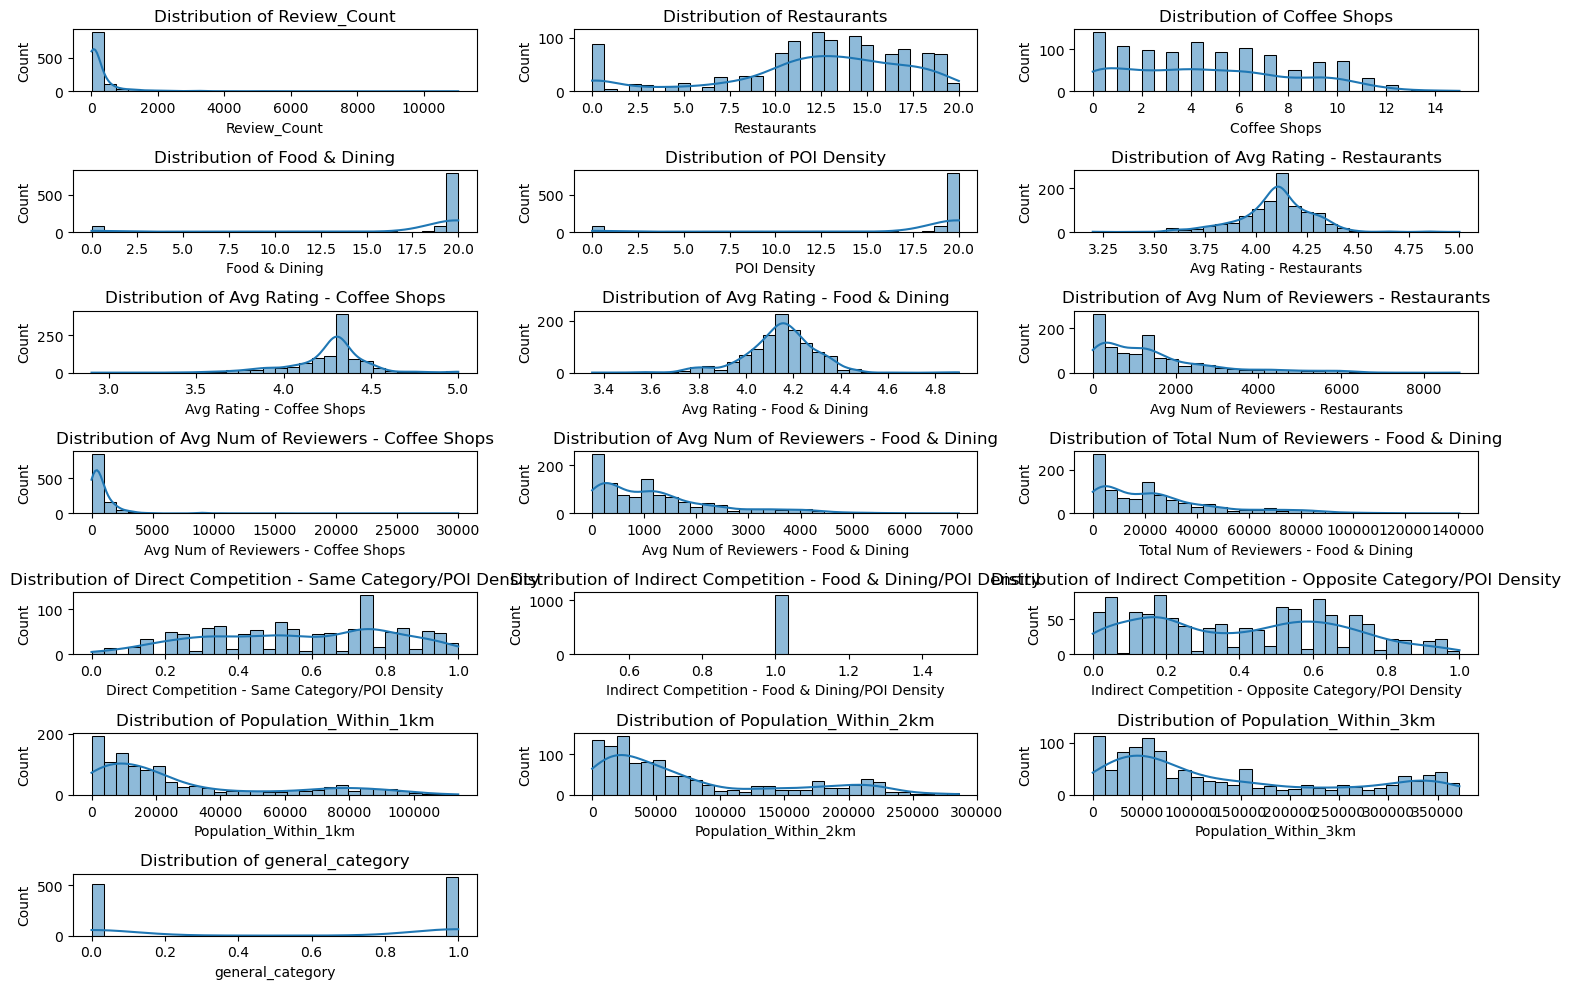

In [382]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot the distribution of all features in a DataFrame
def plot_feature_distributions(df):
    num_cols = df.select_dtypes(include=['number']).columns  # Select only numeric columns
    
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(num_cols, 1):
        plt.subplot((len(num_cols) // 3) + 1, 3, i)  # Create subplots with 3 columns
        sns.histplot(df[col], kde=True, bins=30)  # Histogram with KDE
        plt.title(f'Distribution of {col}')
    
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_feature_distributions(combined_df)


In [391]:
means = combined_df.drop(columns=["keyword", 'Place_id']).mean()
print(means)

Review_Count                                               315.948952
Restaurants                                                 12.095716
Coffee Shops                                                 4.757521
Food & Dining                                               17.278031
POI Density                                                 17.278031
Avg Rating - Restaurants                                     4.100031
Avg Rating - Coffee Shops                                    4.257165
Avg Rating - Food & Dining                                   4.145340
Avg Num of Reviewers - Restaurants                        1445.412611
Avg Num of Reviewers - Coffee Shops                        954.200235
Avg Num of Reviewers - Food & Dining                      1262.348711
Total Num of Reviewers - Food & Dining                   24950.108478
Direct Competition - Same Category/POI Density               0.568471
Indirect Competition - Food & Dining/POI Density             1.000000
Indirect Competition

### Outliers Detection

In [393]:
# Select only numeric columns, excluding "Number of Reviews"
numeric_features = combined_df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col != "Review_Count"]

# Function to detect outliers using IQR and count records with any outlier
def detect_outliers_iqr(df, features):
    outlier_counts = {}
    outlier_mask = np.zeros(df.shape[0], dtype=bool)  # Boolean mask to track rows with outliers

    for feature in features:
        Q1 = df[feature].quantile(0.25)  # First quartile
        Q3 = df[feature].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile Range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Create a mask for outliers in this feature
        feature_outliers = (df[feature] < lower_bound) | (df[feature] > upper_bound)
        outlier_counts[feature] = feature_outliers.sum()  # Count outliers per feature
        outlier_mask |= feature_outliers  # Combine with the overall mask

    # Count records that contain at least one outlier
    num_records_with_outliers = np.sum(outlier_mask)
    
    return outlier_counts, num_records_with_outliers

# Detect outliers
outlier_results, num_outlier_records = detect_outliers_iqr(combined_df, features)

# Print the number of outliers for each feature
print("Outlier Counts Per Feature:")
for feature, count in outlier_results.items():
    print(f"{feature}: {count} outliers")

# Print the number of records that contain at least one outlier
print(f"\nNumber of records containing at least one outlier: {num_outlier_records}")


Outlier Counts Per Feature:
Restaurants: 88 outliers
Coffee Shops: 2 outliers
Food & Dining: 198 outliers
POI Density: 198 outliers
Avg Rating - Restaurants: 60 outliers
Avg Rating - Coffee Shops: 138 outliers
Avg Rating - Food & Dining: 54 outliers
Avg Num of Reviewers - Restaurants: 66 outliers
Avg Num of Reviewers - Coffee Shops: 85 outliers
Avg Num of Reviewers - Food & Dining: 49 outliers
Total Num of Reviewers - Food & Dining: 42 outliers
Direct Competition - Same Category/POI Density: 0 outliers
Indirect Competition - Food & Dining/POI Density: 0 outliers
Indirect Competition - Opposite Category/POI Density: 0 outliers
Population_Within_1km: 79 outliers
Population_Within_2km: 9 outliers
Population_Within_3km: 0 outliers
general_category: 0 outliers

Number of records containing at least one outlier: 470


### Data Transformation

In [ ]:
# Data Transformation and Scaling with QuantileTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler

# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
# Q1 = transformed_df['Popularity'].quantile(0.25)
# Q3 = transformed_df['Popularity'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()

# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply QuantileTransformer (normalize distribution)
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)  
# output_distribution='normal' ensures normal-like distribution
transformed_df[num_cols] = quantile_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
#minmax_scaler = MinMaxScaler()
#transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()


transformed_df


In [ ]:
#Data Transformation and Scaling
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
"""
# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
#Q1 = transformed_df['Popularity'].quantile(0.25)
#Q3 = transformed_df['Popularity'].quantile(0.75)
#IQR = Q3 - Q1
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
#transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()
# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on each transformed feature
normality_results = {}
for col in num_cols:
    shapiro_test_stat, shapiro_p_value = shapiro(transformed_df[col])
    normality_results[col] = {
        "Shapiro-Wilk Test Statistic": shapiro_test_stat,
        "p-value": shapiro_p_value,
        "Normality": "Yes" if shapiro_p_value > 0.05 else "No"
    }

# Convert results to DataFrame
normality_df = pd.DataFrame(normality_results).T

# Display normality test results
#print("\nShapiro-Wilk Normality Test Results:")
#print(normality_df)

# Optionally, save results to a CSV file
#normality_df.to_csv("normality_test_results.csv", index=True)

# Q-Q Plots for each transformed feature
#fig, axes = plt.subplots(nrows=len(num_cols), figsize=(6, len(num_cols) * 3))

#for i, col in enumerate(num_cols):
#    probplot(transformed_df[col], dist="norm", plot=axes[i])
#    axes[i].set_title(f"Q-Q Plot: {col}")

#plt.tight_layout()
#plt.show()
transformed_df
"""

## Dataset Splitting

In [395]:
food_chains = pd.read_csv("final_dammam_food_chains_categorized.csv")
coffee_chains = food_chains[food_chains['general_category'] == 0]
restaurants_chains = food_chains[food_chains['general_category'] == 1]

print("\nRestaurants chain count")
# Group by 'keyword' and count the number of occurrences
keyword_counts = restaurants_chains.groupby('keyword').size().reset_index(name='count')
print(keyword_counts)

print("\nCoffee chains count")
# Group by 'keyword' and count the number of occurrences
keyword_counts = coffee_chains.groupby('keyword').size().reset_index(name='count')
print(keyword_counts)


filtered_restaurants = restaurants_chains[restaurants_chains['keyword'].isin(["McDonald's", "Herfy", "Domino's"])]
filtered_coffee = coffee_chains[coffee_chains['keyword'].isin(["Dunkin", "Costa"])]



Restaurants chain count
          keyword  count
0          Albaik      9
1     Burger King     19
2        Domino's     37
3      Hamburgini      4
4        Hardee's     23
5           Herfy     35
6      Jan Burger      1
7             KFC     34
8            Kudo     17
9   Maestro Pizza     25
10     McDonald's     42
11      Pizza Hut     12
12      Shawarmer     11

Coffee chains count
        keyword  count
0        Barn’s     59
1    Camel Step      1
2         Costa     22
3     Dose Cafe     14
4      Dr. Cafe      8
5        Dunkin     74
6  Krispy Kreme     23
7      Overdose      2
8     Starbucks     71
9   Tim Hortons     39


In [399]:
# Separate based on 'general_category'
coffee_df = combined_df[combined_df['general_category'] == 0].reset_index(drop=True)
restaurant_df = combined_df[combined_df['general_category'] == 1].reset_index(drop=True)

# Optional: print shapes to confirm
print(f"Coffee Shops: {coffee_df.shape[0]} rows")
print(f"Restaurants: {restaurant_df.shape[0]} rows")

# --- Training and Testing ----

# Split combined_df into 80% train and 20% test
combined_df_train, combined_df_test = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=42,  # for reproducibility
    shuffle=True      # ensure data is shuffled before splitting
)

# Optional: Print shape summary
print(f"Train set size: {combined_df_train.shape[0]}")
print(f"Test set size: {combined_df_test.shape[0]}")

# Define test keywords - Using specific food-chain
test_coffee_keyword = "Dunkin"
test_restaurant_keyword = "McDonald's"

# Coffee: train/test split
#coffee_test = combined_df[combined_df['Place_id'].isin(filtered_coffee['Place_id'])].reset_index(drop=True)
#coffee_train = combined_df[~combined_df['Place_id'].isin(filtered_coffee['Place_id'])].reset_index(drop=True)


# Restaurant: train/test split
#restaurant_test = combined_df[combined_df['Place_id'].isin(filtered_restaurants['Place_id'])].reset_index(drop=True)
#restaurant_train = combined_df[~combined_df['Place_id'].isin(filtered_restaurants['Place_id'])].reset_index(drop=True)

# Print results
#print("Coffee - Train:", coffee_train.shape[0], "Test:", coffee_test.shape[0])
#print("Restaurant - Train:", restaurant_train.shape[0], "Test:", restaurant_test.shape[0])


Coffee Shops: 511 rows
Restaurants: 586 rows
Train set size: 877
Test set size: 220


## Features Analyses 

### Pearson correlation

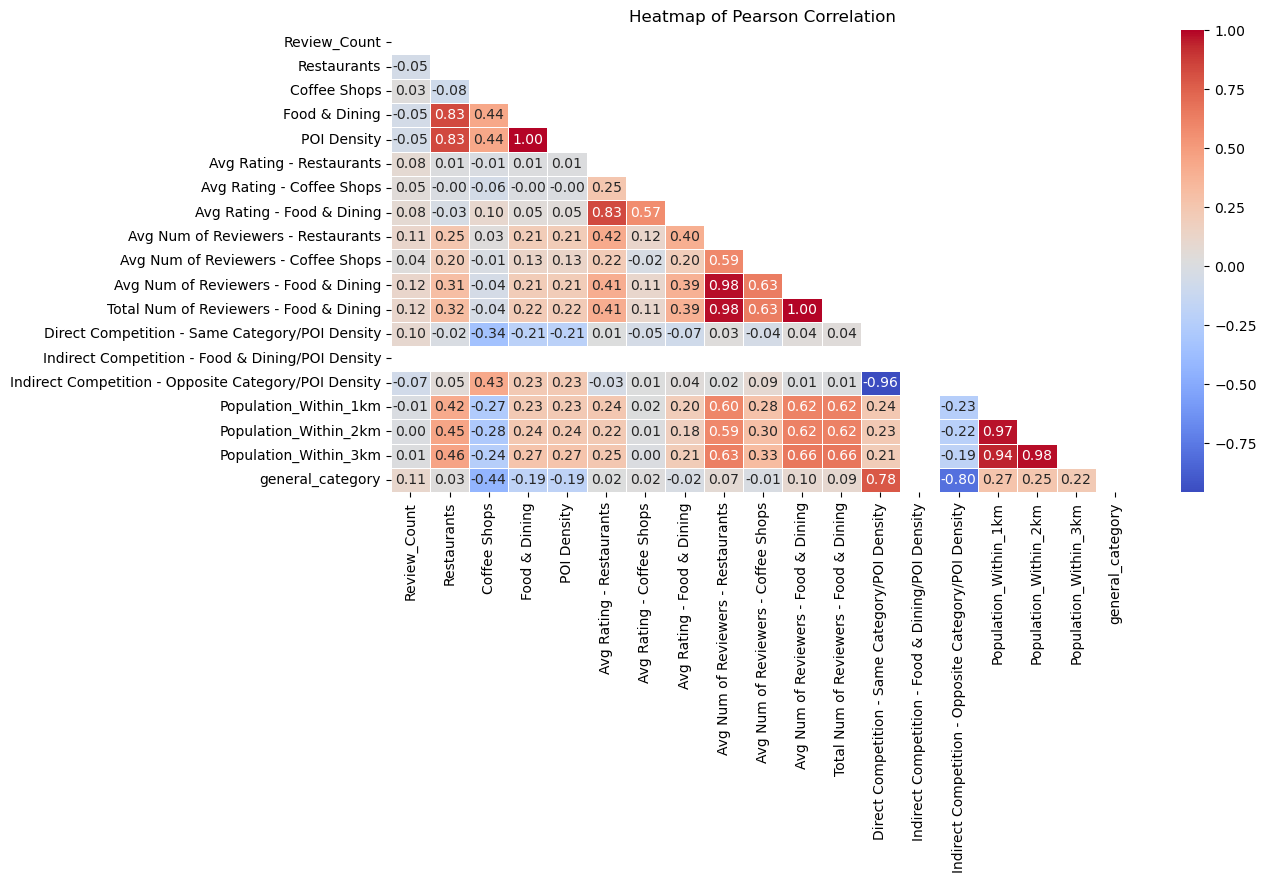

In [401]:
# Compute Pearson correlation

corr_matrix = combined_df.select_dtypes(include=['number']).corr()

# Create a mask for the upper triangular part
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Heatmap of Pearson Correlation")
plt.show()


### Scatterplots

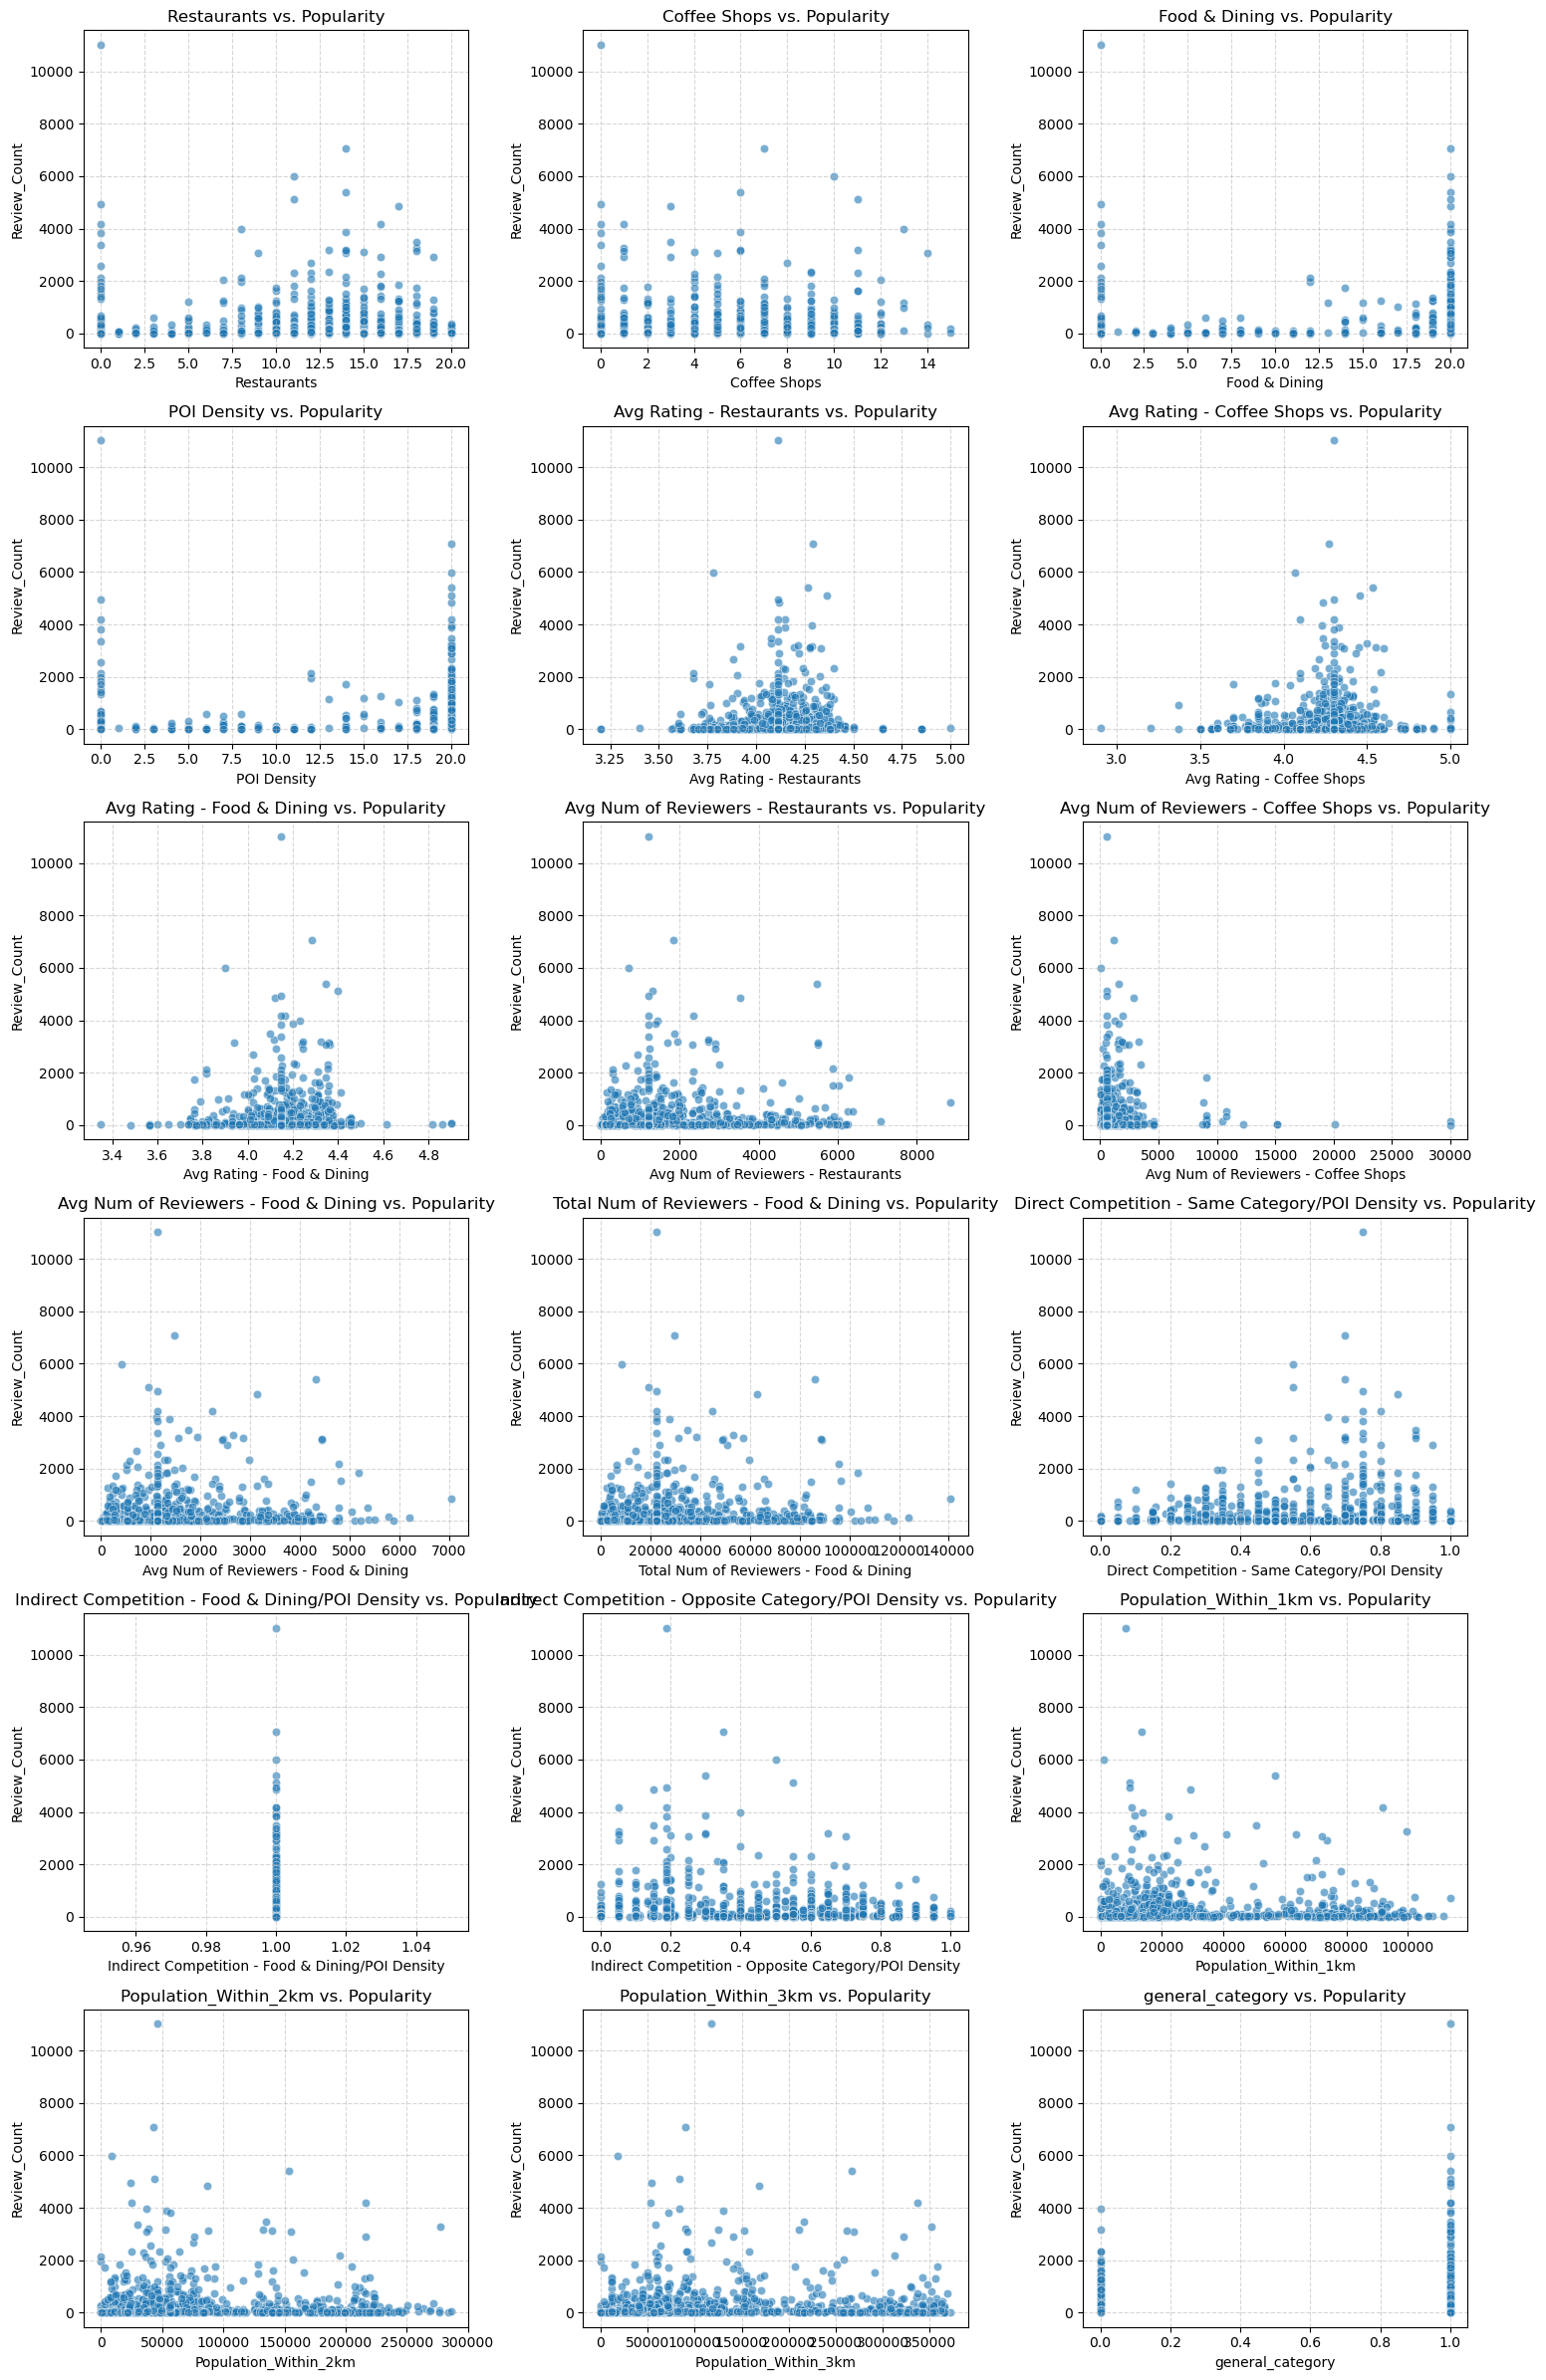

In [403]:
# Original Dataframe (WITHOUT transformation)
# Filter only numeric features (excluding target variable "Number of Reviewers")
numeric_features = combined_df.select_dtypes(include=np.number).columns
features_to_plot = [feature for feature in numeric_features if feature != "Review_Count"]

# Define grid size
num_features = len(features_to_plot)
num_cols = 3  # Number of columns in the grid
num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  # Compute required rows

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

# Loop through features and create scatter plots
for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=combined_df[feature], y=combined_df["Review_Count"], alpha=0.6, ax=axes[i])
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("Review_Count", fontsize=10)
    axes[i].set_title(f"{feature} vs. Popularity", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots if num_features < num_cols*num_rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove unused subplots

# Adjust layout
plt.tight_layout()
plt.show()


# Experiment 1: 80% - 20% dataset

### X and y Variables

In [412]:
# -----------------------------
# Step 1: Define features and target
# -----------------------------

# Columns to drop
columns_to_drop = [
    'Review_Count', 'keyword', 'Place_id', 'Indirect Competition - Food & Dining/POI Density', 
    'Population_Within_2km', 'Population_Within_3km',
    'Religious Institutions', 'Public & Government Services', 'Health',
    'Home & Construction Services', 'Education', 'Avg Rating - Restaurants',
    'Avg Rating - Coffee Shops', 'Avg Num of Reviewers - Restaurants',
    'Avg Num of Reviewers - Coffee Shops',
    'Hotels & Hospitality', 'Finance & Services', 'Transportation & Travel',
    'Restaurants', 'Coffee Shops', 'Food & Dining'
]


#training 
X_train = coffee_train.drop(columns=columns_to_drop, errors='ignore')
y_train = coffee_train['Review_Count']

#testing
X_test = coffee_test.drop(columns=columns_to_drop, errors='ignore')
y_test = coffee_test['Review_Count'].values

### Remove Highly Correlated features

In [414]:
# -----------------------------
# Step 2: Remove highly correlated features
# -----------------------------

def remove_highly_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

X_train, removed_corr_features = remove_highly_correlated_features(X_train, threshold=0.95)
X_columns = X_train.columns
X_test = X_test[X_columns]

print(f"Removed highly correlated features: {removed_corr_features}")


Removed highly correlated features: ['Total Num of Reviewers - Food & Dining', 'Indirect Competition - Opposite Category/POI Density']


In [416]:
X_train.columns

Index(['POI Density', 'Avg Rating - Food & Dining',
       'Avg Num of Reviewers - Food & Dining',
       'Direct Competition - Same Category/POI Density',
       'Population_Within_1km', 'general_category'],
      dtype='object')

### Transformation and Scaling

In [418]:
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Initialize PowerTransformer for X
pt = PowerTransformer(method='yeo-johnson', standardize=False)  # Set standardize=False since we'll use MinMaxScaler next
scaler = MinMaxScaler()

# Fit on train and apply to both train and test
X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train))
X_test_transformed = scaler.transform(pt.transform(X_test))

# Reshape y to 2D arrays (required by sklearn scalers)
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Initialize separate transformers for y
pt_y = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_y = MinMaxScaler()

# Fit on training target and transform both y_train and y_test
y_train_transformed = scaler_y.fit_transform(pt_y.fit_transform(y_train_reshaped)).ravel()
y_test_transformed = scaler_y.transform(pt_y.transform(y_test_reshaped)).ravel()


## Random Forest

#### Model Training and Testing

In [426]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import ndcg_score



# -----------------------------
# Step 4: Grid Search - Random Forest
# -----------------------------

rf_model = RandomForestRegressor(random_state= None)

param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(rf_model, param_grid, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train_transformed, y_train_transformed)

y_pred = grid_search.best_estimator_.predict(X_test_transformed)


# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
y_pred = qt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()


# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")


Fitting 5 folds for each of 288 candidates, totalling 1440 fits

--- Best Model Parameters ---
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

--- Regression Metrics ---
R² Score:   -56.388
MSE:        13000586.667
RMSE:       3605.633
MAE:        3551.546

--- Ranking Metrics ---
nDCG@10:   0.377
nSD@10:    0.400


#### Features Importance

In [434]:
# Compute feature importance from the best estimator
best_rf_model = grid_search.best_estimator_
feature_importance = best_rf_model.feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()

# Display feature importance values
print("\nFeature Importance Scores:")
print(feature_importance_df)

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'

### XGBoost

In [427]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score

# -----------------------------
# Step 4: Grid Search - XGBoost
# -----------------------------

xgb_model = XGBRegressor(objective='reg:squarederror', random_state= None)

param_grid = {
    'n_estimators': [50, 100, 200],         # Number of trees
    'max_depth': [3, 5, 6, 10],             # Maximum depth of trees
    'learning_rate': [0.01, 0.1, 0.2, 0.3], # Learning rate
    'subsample': [0.8, 1],                  # Subsample ratio
    'colsample_bytree': [0.8, 1]            # Feature fraction per tree
}


grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    cv=3
)

grid_search.fit(X_train_transformed, y_train_transformed)

y_pred = grid_search.best_estimator_.predict(X_test_transformed)


# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
y_pred = qt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()


# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")


Fitting 3 folds for each of 192 candidates, totalling 576 fits

--- Best Model Parameters ---
{'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

--- Regression Metrics ---
R² Score:   -61.243
MSE:        14100397.662
RMSE:       3755.050
MAE:        3725.457

--- Ranking Metrics ---
nDCG@10:   0.344
nSD@10:    0.400


### SVR

In [428]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    median_absolute_error, max_error, ndcg_score
)
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler
import warnings

#warnings.filterwarnings("ignore")  # Optional: suppress warnings for cleaner output

# -----------------------------
# Step 2: Clean & Scale
# -----------------------------

# Remove constant features
constant_features = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train = X_train.drop(columns=constant_features)
X_test = X_test.drop(columns=constant_features)
print(f"Removed constant features: {constant_features}")

# Check for NaNs or infinite values
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected.")

check_nan_inf(X_train, y_train)


# -----------------------------
# Step 3: Define SVR Model & Grid Search
# -----------------------------

model = Pipeline([
    ('svr', SVR())
])

param_grid = {
    'svr__C': [0.01, 0.1, 1, 10],
    'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__kernel': ['rbf', 'sigmoid']
}


grid_search = GridSearchCV(model, param_grid, scoring="r2", cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_transformed, y_train_transformed)

# -----------------------------
# Step 4: Predict & Evaluate
# -----------------------------

y_pred = grid_search.best_estimator_.predict(X_test_transformed)


# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
y_pred = qt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")


print("\n🎉 Model evaluation completed!")


Removed constant features: []
Fitting 5 folds for each of 192 candidates, totalling 960 fits

--- Best Model Parameters ---
{'svr__C': 0.1, 'svr__epsilon': 0.1, 'svr__gamma': 'auto', 'svr__kernel': 'rbf'}

--- Regression Metrics ---
R² Score:   -59.162
MSE:        13629017.497
RMSE:       3691.750
MAE:        3657.503

--- Ranking Metrics ---
nDCG@10:   0.277
nSD@10:    0.400

🎉 Model evaluation completed!


### LSTM

In [429]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
import numpy as np

# -----------------------------
# Step 1: Convert Data to Torch Tensors
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reshape input for LSTM: (samples, time_steps, features)
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32).unsqueeze(1).to(device)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32).unsqueeze(1).to(device)
y_train_tensor = torch.tensor(y_train_transformed, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_transformed, dtype=torch.float32).to(device)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# -----------------------------
# Step 2: Define LSTM Model
# -----------------------------

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # output shape: (batch, seq_len, hidden)
        out = self.fc(lstm_out[:, -1, :])  # Take the last time step
        return out.squeeze()

model = LSTMRegressor(input_size=X_train_tensor.shape[2]).to(device)

# -----------------------------
# Step 3: Train the Model
# -----------------------------

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 100
model.train()
for epoch in range(n_epochs):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss:.4f}")

# -----------------------------
# Step 4: Make Predictions
# -----------------------------

model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)

y_pred = y_pred_tensor.cpu().numpy()

# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
y_pred = qt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Model: LSTM Regressor ---")
print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")


Epoch 10/100 - Loss: 1.6051
Epoch 20/100 - Loss: 1.5778
Epoch 30/100 - Loss: 1.5648
Epoch 40/100 - Loss: 1.5620
Epoch 50/100 - Loss: 1.5475
Epoch 60/100 - Loss: 1.5638
Epoch 70/100 - Loss: 1.5477
Epoch 80/100 - Loss: 1.5546
Epoch 90/100 - Loss: 1.5241
Epoch 100/100 - Loss: 1.5356

--- Model: LSTM Regressor ---

--- Regression Metrics ---
R² Score:   -58.423
MSE:        13461616.462
RMSE:       3669.008
MAE:        3628.119

--- Ranking Metrics ---
nDCG@10:   0.281
nSD@10:    0.400
